# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

df = pd.read_csv('titanic_passengers.csv')

In [2]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

# Checking basic info

In [3]:
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# the cabin columns has way to many missing values so i dropped it
df = df.drop(columns=['Cabin'])

In [7]:
#for embarked, i filled in the missing values with the mode and median for age
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [11]:
# just making sure 'age' is an int not a float so i can do calculations and groupings later
df['Age'] = pd.to_numeric(df['Age']).astype(int)

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S


In [13]:
# here i'm adding two new columns, 'companion' adds up how many family members each passenger had
#'alone' is 1 if they had no one with them and 0 if they traveled with someone, just so i can check if being alone affected survival 
df["Companions"] = df["SibSp"].fillna(0) + df["Parch"].fillna(0)
df["Alone"] = (df["Companions"] == 0).astype(int)

In [14]:
# using .loc to split ages into simple groups, so it makes it easier to see survival patterns by age group
df["AgeGroup"] = "Unknown"

df.loc[df["Age"] < 13, "AgeGroup"] = "Child"
df.loc[(df["Age"] >= 13) & (df["Age"] < 18), "AgeGroup"] = "Teen"
df.loc[(df["Age"] >= 18) & (df["Age"] < 50), "AgeGroup"] = "Adult"
df.loc[df["Age"] >= 50, "AgeGroup"] = "Senior"

In [15]:
# i'm using the quartile to divide fares into groups to compare survival across different fare ranges 
q1, q2, q3 = df["Fare"].quantile([.25,.5,.75])

In [16]:
df["FareGroup"] = "Unknown"

df.loc[df["Fare"] <= q1, "FareGroup"] = "Low"
df.loc[(df["Fare"] > q1) & (df["Fare"] <= q2), "FareGroup"] = "Med-Low"
df.loc[(df["Fare"] > q2) & (df["Fare"] <= q3), "FareGroup"] = "Med-High"
df.loc[df["Fare"] > q3, "FareGroup"] = "High"

# Visualizations

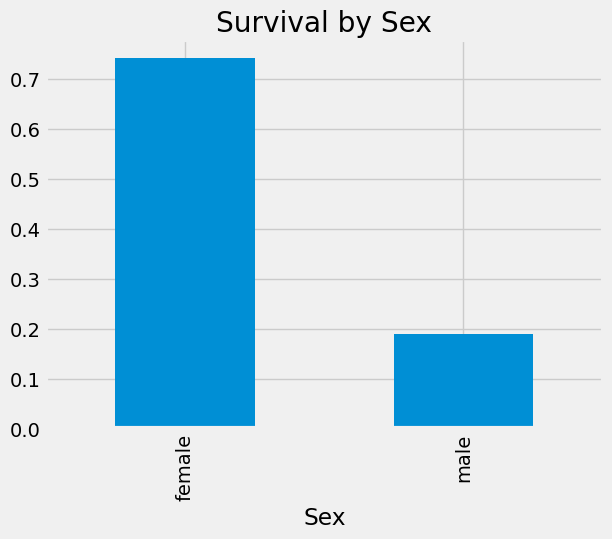

In [17]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival by Sex")
plt.show()

This chart shows how survival rates differ between men and women. You can see that way more women survived, probably just because of the whole women and kids first thing.

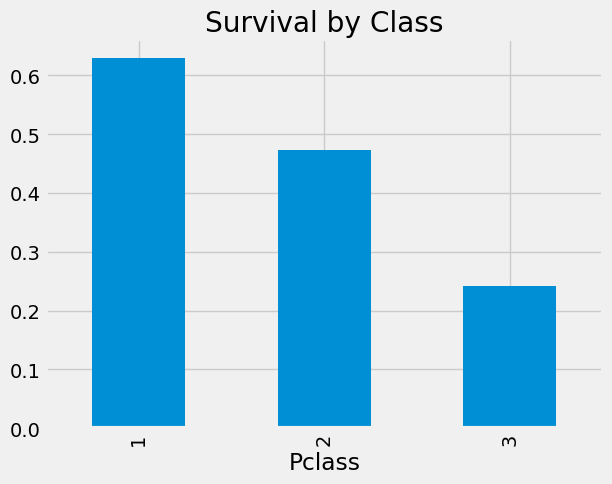

In [18]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival by Class")
plt.show()

Here I’m looking at how survival rates differ by ticket class. First class had the highest survival rate, and third class had the lowest, makes sense since the wealthy passengers were closer to the lifeboats.

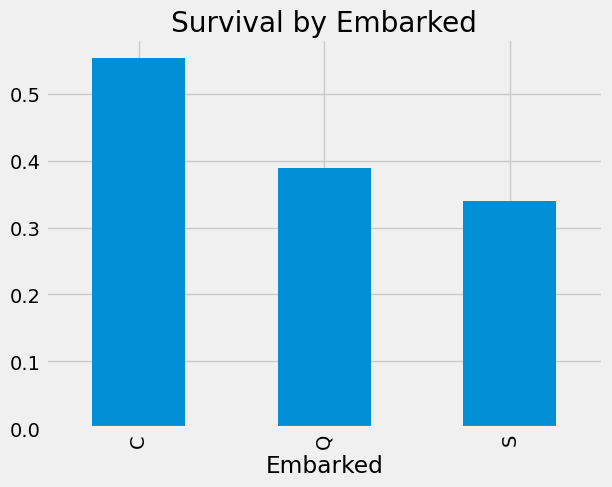

In [19]:
df.groupby("Embarked")["Survived"].mean().plot(kind="bar")
plt.title("Survival by Embarked")
plt.show()

This one shows where people boarded the ship and how that impacted their chances of survival. Looks like passengers who got on at Cherbourg (C) had a better shot than those from the other ports.

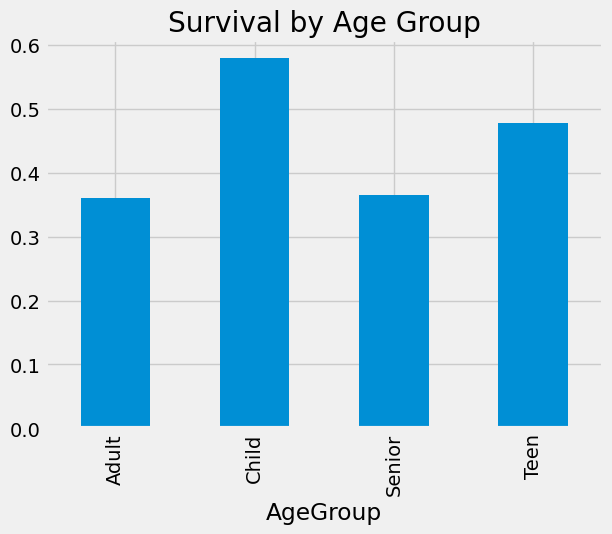

In [20]:
df.groupby("AgeGroup")["Survived"].mean().plot(kind="bar")
plt.title("Survival by Age Group")
plt.show()

This shows survival by age group, kids, teens, adults, and seniors. Kids made it out the most, which makes sense with the whole women and children first.

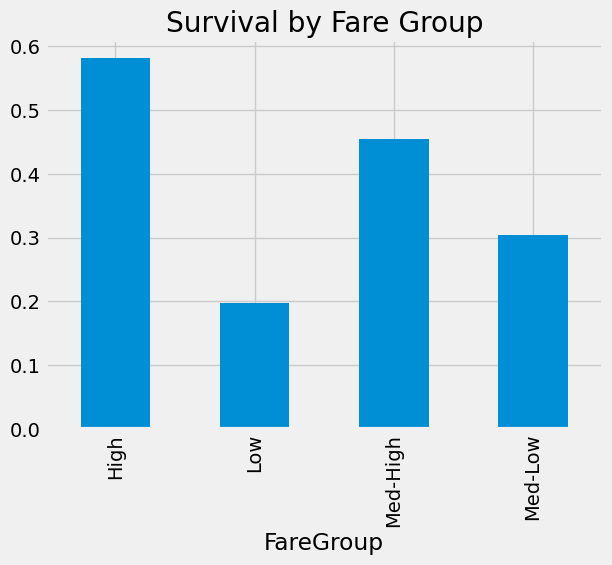

In [21]:
df.groupby("FareGroup")["Survived"].mean().plot(kind="bar")
plt.title("Survival by Fare Group")
plt.show()

Here I’m seeing if ticket price mattered. Turns out people who paid more had better chances of surviving, probably because they were in first class.

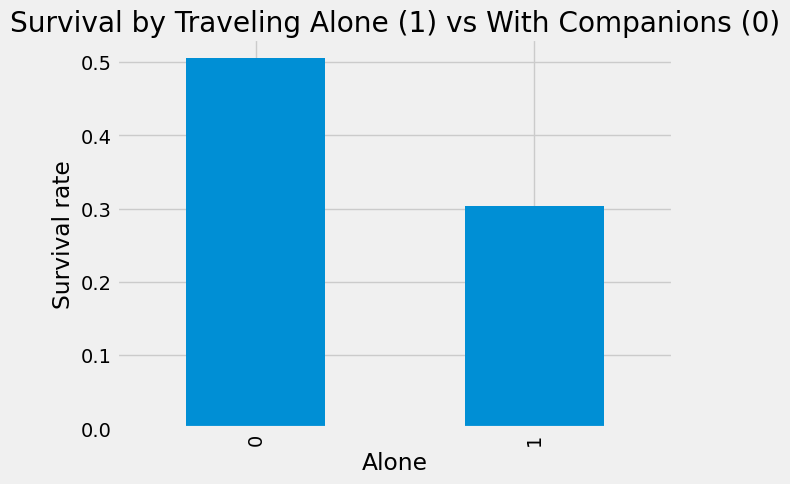

In [22]:
df.groupby("Alone")["Survived"].mean().plot(kind="bar")
plt.title("Survival by Traveling Alone (1) vs With Companions (0)")
plt.ylabel("Survival rate")
plt.show()

This shows people who were alone versus those with family. Looks like the ones with family did better, probably helped having someone to stick with when the sinking happened.

# Filtering most likely and least likely to survive

In [23]:
most = df[(df["Sex"]=="female") & (df["Pclass"]==1) & (df["Alone"]==0)]
most[["Name","Sex","Age","Pclass","Embarked","Survived"]].head()

,Name,Sex,Age,Pclass,Embarked,Survived
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,C,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,S,1
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28,1,C,1
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49,1,C,1
88,"Fortune, Miss. Mabel Helen",female,23,1,S,1


In [24]:
least = df[(df["Sex"]=="male") & (df["Pclass"]==3) & (df["Alone"]==1)]
least[["Name","Sex","Age","Pclass","Embarked","Survived"]].head()

,Name,Sex,Age,Pclass,Embarked,Survived
4,"Allen, Mr. William Henry",male,35,3,S,0
5,"Moran, Mr. James",male,28,3,Q,0
12,"Saundercock, Mr. William Henry",male,20,3,S,0
26,"Emir, Mr. Farred Chehab",male,28,3,C,0
29,"Todoroff, Mr. Lalio",male,28,3,S,0


# Passenger most likely to survive

**Name:** Mrs. Florence Briggs Thayer Cumings  

**Sex:** Female  

**Class:** 1st  

**Age:** 38  

**Embarked:** C  

**Companions:** Not alone

**Fact:** According to the records, she escaped in Lifeboat 4 with other first class passengers and survived the sinking.

# Passenger least likely to survive

**Name:** Mr. William Henry Allen  

**Sex:** Male 

**Class:** 3rd  

**Age:** 35  

**Embarked:** S  

**Companions:** Alone  

**Fact:** Records show he was a third class passenger traveling alone and did not survive the disaster. A suitcase belonging to Allen was recovered from the wreck in 2000. It contained clothing that bore a laundry stamp "W. Allen".